In [1]:
print("Project is set up and working!")

Project is set up and working!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
df = pd.read_csv('UCI_Credit_Card.csv')
print("Data loaded!")
print("Rows and columns:", df.shape)
print(df.head())

Data loaded!
Rows and columns: (30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.pa

In [7]:
print("Column names:")
print(df.columns.tolist())

print("\nHow many defaults vs non-defaults:")
print(df['default.payment.next.month'].value_counts())

Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']

How many defaults vs non-defaults:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


In [9]:
# Select the columns I'll use to predict default
X = df[['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1']]

# This is what I'm trying to predict
y = df['default.payment.next.month']

print( "Input data shape:", X.shape)
print( "Target data shape:", y.shape)
print("\nFirst 5 rows of inputs:")
print(X.head())

Input data shape: (30000, 5)
Target data shape: (30000,)

First 5 rows of inputs:
   LIMIT_BAL  AGE  PAY_0  BILL_AMT1  PAY_AMT1
0    20000.0   24      2     3913.0       0.0
1   120000.0   26     -1     2682.0       0.0
2    90000.0   34      0    29239.0    1518.0
3    50000.0   37      0    46990.0    2000.0
4    50000.0   57     -1     8617.0    2000.0


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 24000
Testing rows: 6000


In [19]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy: .2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Model Accuracy:  80.85%

Confusion Matrix:
[[4542  145]
 [1004  309]]


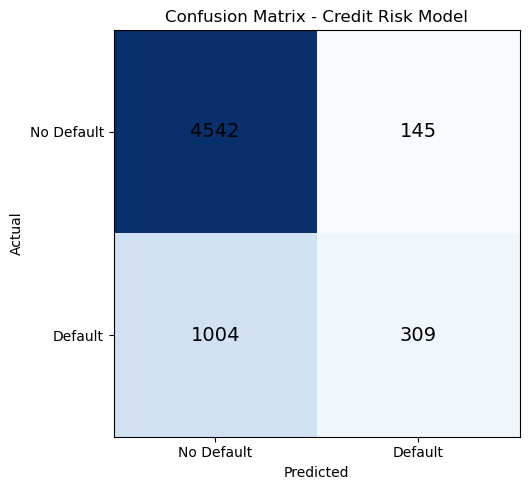

Chart saved to outputs folder!


In [23]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, predictions)
labels = ['No Default', 'Default']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Credit Risk Model')

for i in range (2):
    for j in range (2):
        ax.text(j, i, cm[i, j],  ha='center', va='center',
                 color='black', fontsize=14)

plt.tight_layout()
plt.savefig('outputs/credit_risk_confusion_matrix.png')
plt.show()

print("Chart saved to outputs folder!")